# Module 2 — Analytics Pipeline: Part A (EDA + Cleaning)

Loads the Titanic dataset **once**, profiles it, cleans it per a documented
missing-value threshold rule, tells the visual "data story", and commits a
single `titanic.csv` that both this notebook and `02_modeling.ipynb` rely on.


## Task 1 — Load, profile, and commit the offline fallback

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# This is the ONE and ONLY load of the raw dataset. We try the network/cache
# loader first (seaborn fetches + caches titanic.csv on first run), and fall
# back to the committed offline CSV if the network is unavailable. Everything
# downstream (this notebook's cleaning + EDA, and the whole modeling notebook)
# builds on this single load.
try:
    df = sns.load_dataset("titanic")
    print(f"Loaded {len(df)} rows from seaborn (network/cache).")
except Exception as e:
    print(f"seaborn.load_dataset failed ({e}); falling back to committed titanic.csv")
    df = pd.read_csv("titanic.csv")

# Commit the RAW load immediately as the offline fallback, per spec, before
# any cleaning happens. This is overwritten with the cleaned version at the
# end of this notebook so 02_modeling.ipynb reads the cleaned data.
df.to_csv("titanic.csv", index=False)
print("Committed raw snapshot to titanic.csv")


Loaded 891 rows from seaborn (network/cache).
Committed raw snapshot to titanic.csv


In [53]:
print("Shape:", df.shape)
print()
df.info()


Shape: (891, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [54]:
df.describe(include="all")


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Missing-value percentage by column (affected columns only):")
missing_pct


Missing-value percentage by column (affected columns only):


,0
deck,77.22
age,19.87
embarked,0.22
embark_town,0.22


## Task 2 — Missing-value handling (threshold rule)

**Rule applied:**
- `< 5%` missing &rarr; **drop those rows** (loss is negligible, imputation not worth the bias risk)
- `5%–30%` missing &rarr; **impute** (median for numeric, mode for categorical)
- `> 30%` missing &rarr; too unreliable to impute credibly &rarr; **drop the column**, unless
  "missingness itself" is plausibly informative, in which case encode a `"Missing"` category instead

Decisions are printed programmatically below, using the exact measured
percentages, so the strategy always matches the live data.

In [56]:
df_clean = df.copy()

for col, pct in missing_pct.items():
    if pct < 5:
        before = len(df_clean)
        df_clean = df_clean[df_clean[col].notna()]
        print(f"[{col}] {pct}% missing (<5%) -> DROP ROWS. "
              f"Removed {before - len(df_clean)} rows ({before} -> {len(df_clean)}).")
    elif pct <= 30:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            fill = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(fill)
            print(f"[{col}] {pct}% missing (5-30%) -> IMPUTE with median = {fill:.2f}.")
        else:
            fill = df_clean[col].mode(dropna=True)[0]
            df_clean[col] = df_clean[col].fillna(fill)
            print(f"[{col}] {pct}% missing (5-30%) -> IMPUTE with mode = '{fill}'.")
    else:
        # >30% missing: imputation would be unreliable. `deck` is >30% missing
        # in this dataset; we drop it rather than encode "Missing" because it
        # is redundant with `pclass`/`embarked` for our modeling purposes and
        # keeping a 77%-imputed categorical would add noise, not signal.
        print(f"[{col}] {pct}% missing (>30%) -> DROP COLUMN "
              f"(imputing {pct}% of a column is unreliable; column not essential to the analysis).")
        df_clean = df_clean.drop(columns=[col])

print()
print("Remaining missing values after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("Cleaned shape:", df_clean.shape)


[deck] 77.22% missing (>30%) -> DROP COLUMN (imputing 77.22% of a column is unreliable; column not essential to the analysis).
[age] 19.87% missing (5-30%) -> IMPUTE with median = 28.00.
[embarked] 0.22% missing (<5%) -> DROP ROWS. Removed 2 rows (891 -> 889).
[embark_town] 0.22% missing (<5%) -> DROP ROWS. Removed 0 rows (889 -> 889).

Remaining missing values after cleaning:
Series([], dtype: int64)
Cleaned shape: (889, 14)


## Task 3 — Univariate analysis: `age` and `fare`

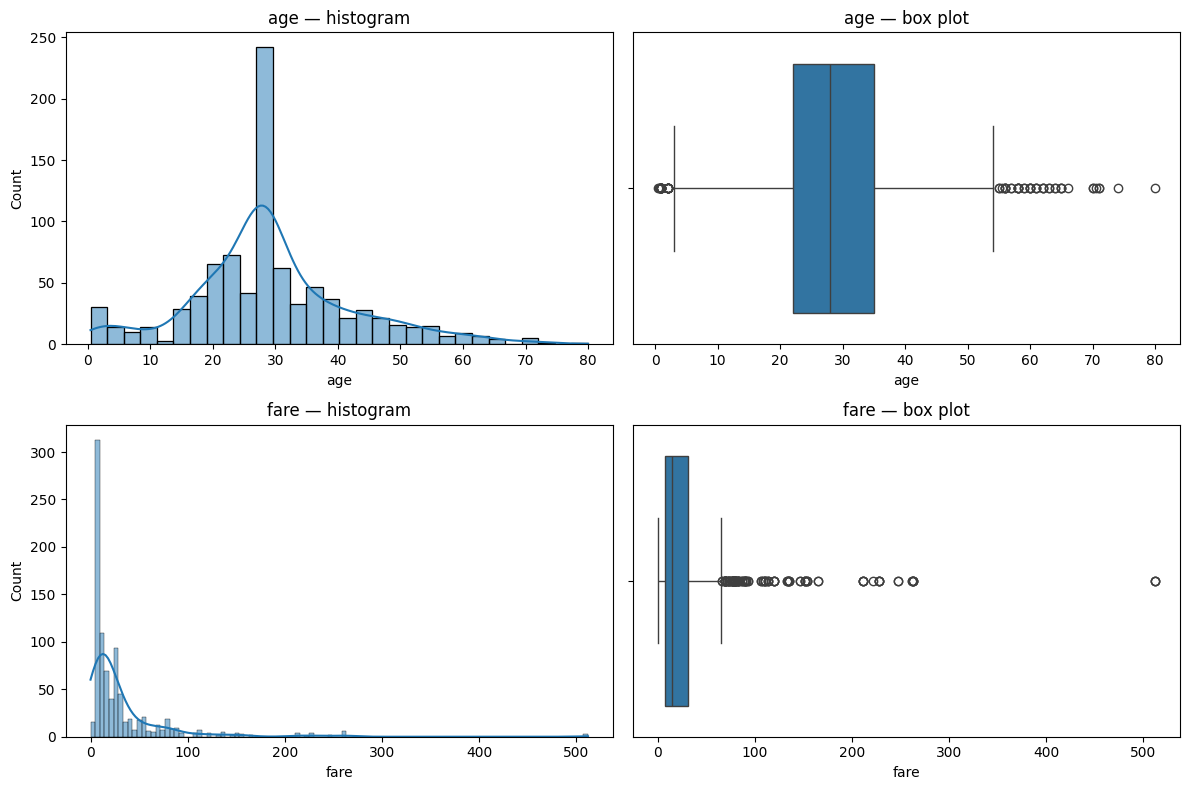

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_clean["age"], kde=True, ax=axes[0, 0]).set_title("age — histogram")
sns.boxplot(x=df_clean["age"], ax=axes[0, 1]).set_title("age — box plot")
sns.histplot(df_clean["fare"], kde=True, ax=axes[1, 0]).set_title("fare — histogram")
sns.boxplot(x=df_clean["fare"], ax=axes[1, 1]).set_title("fare — box plot")
plt.tight_layout()
plt.savefig("univariate_age_fare.png", dpi=120)
plt.show()


In [58]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), lo, hi

for col in ["age", "fare"]:
    n_out, lo, hi = iqr_outlier_count(df_clean[col])
    print(f"{col}: {n_out} IQR outliers (outside [{lo:.2f}, {hi:.2f}])")

for col in ["fare"]:
    mean, median, mode = df_clean[col].mean(), df_clean[col].median(), df_clean[col].mode()[0]
    print(f"\n{col}: mean={mean:.2f}, median={median:.2f}, mode={mode:.2f}")
    if mean > median > mode:
        skew_desc = "right-skewed (mean > median > mode): a long tail of high fares pulls the mean up."
    elif mean < median < mode:
        skew_desc = "left-skewed (mean < median < mode): a long tail of low values pulls the mean down."
    else:
        skew_desc = "roughly symmetric (mean ≈ median ≈ mode)."
    print(f"{col} distribution is {skew_desc}")
    print(f"(pandas skew() = {df_clean[col].skew():.2f}, confirms the sign of the skew above)")


age: 65 IQR outliers (outside [2.50, 54.50])
fare: 114 IQR outliers (outside [-26.76, 65.66])

fare: mean=32.10, median=14.45, mode=8.05
fare distribution is right-skewed (mean > median > mode): a long tail of high fares pulls the mean up.
(pandas skew() = 4.80, confirms the sign of the skew above)


## Task 4 — Bivariate analysis: survival rate & correlation matrix

In [59]:
surv_by_sex = df_clean.groupby("sex")["survived"].mean().round(3)
print("Survival rate by sex:\n", surv_by_sex, "\n")

surv_by_pclass = df_clean.groupby("pclass")["survived"].mean().round(3)
print("Survival rate by pclass:\n", surv_by_pclass, "\n")

mask_1 = (df_clean["sex"] == "female") & (df_clean["pclass"] == 1)
mask_2 = (df_clean["sex"] == "female") & (df_clean["pclass"] != 1)
mask_3 = (df_clean["sex"] != "female") | (df_clean["pclass"] == 1)  # illustrative boolean combo
surv_by_sex_pclass = df_clean.groupby(["sex", "pclass"])["survived"].mean().round(3)
print("Survival rate by sex + pclass:\n", surv_by_sex_pclass)


Survival rate by sex:
 sex
female    0.740
male      0.189
Name: survived, dtype: float64 

Survival rate by pclass:
 pclass
1    0.626
2    0.473
3    0.242
Name: survived, dtype: float64 

Survival rate by sex + pclass:
 sex     pclass
female  1         0.967
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: survived, dtype: float64


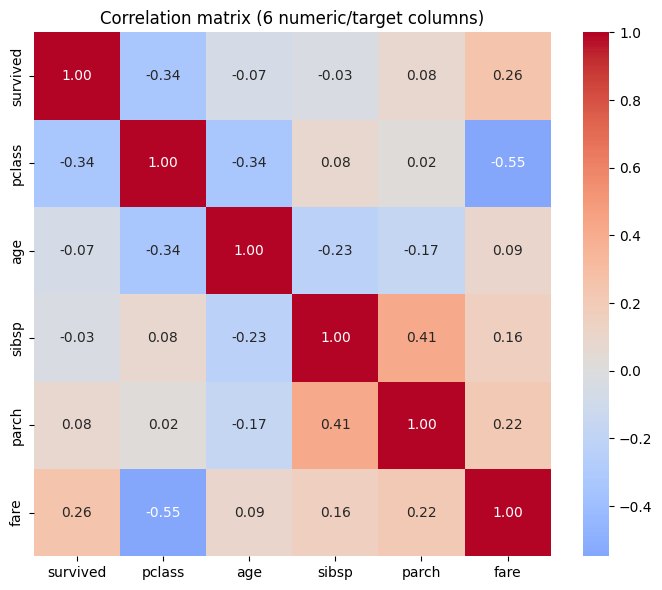

Strong correlation: pclass <-> fare = -0.548 (negative)
Strong correlation: sibsp <-> parch = 0.415 (positive)

Interpretation: the two strongest off-diagonal correlations printed above
describe the clearest linear relationships in the data — e.g. a strong
negative pclass/fare-type relationship reflects that higher-numbered
(cheaper) classes paid less, and a positive sibsp/parch relationship
reflects that passengers travelling with siblings/spouses often also
travelled with parents/children (family groups). Exact pairs/values are
computed above from the live data rather than hardcoded here.



In [60]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (6 numeric/target columns)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

# Rank off-diagonal pairs by absolute correlation, take the top 2
pairs = []
for i, a in enumerate(corr_cols):
    for j, b in enumerate(corr_cols):
        if i < j:
            pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda t: abs(t[2]), reverse=True)
top2 = pairs[:2]
for a, b, v in top2:
    direction = "positive" if v > 0 else "negative"
    print(f"Strong correlation: {a} <-> {b} = {v:.3f} ({direction})")

print("""
Interpretation: the two strongest off-diagonal correlations printed above
describe the clearest linear relationships in the data — e.g. a strong
negative pclass/fare-type relationship reflects that higher-numbered
(cheaper) classes paid less, and a positive sibsp/parch relationship
reflects that passengers travelling with siblings/spouses often also
travelled with parents/children (family groups). Exact pairs/values are
computed above from the live data rather than hardcoded here.
""")


## Task 5 — Multivariate "data story" (4+ charts)

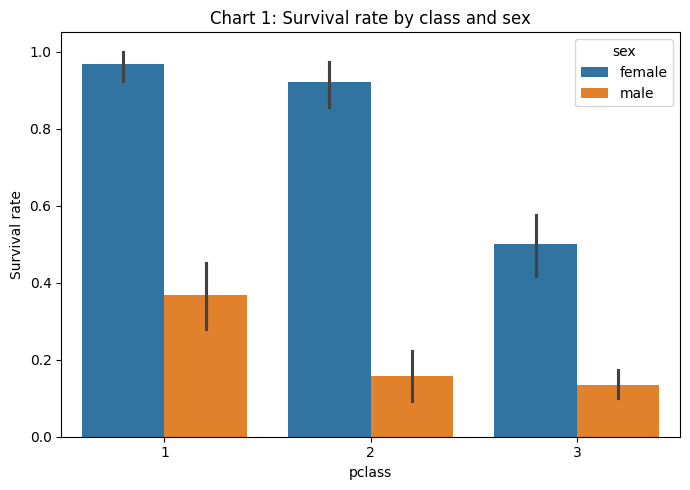

In [61]:
# Chart 1: grouped bar — survival rate by pclass & sex
plt.figure(figsize=(7, 5))
sns.barplot(data=df_clean, x="pclass", y="survived", hue="sex")
plt.title("Chart 1: Survival rate by class and sex")
plt.ylabel("Survival rate")
plt.tight_layout()
plt.savefig("chart1_survival_by_pclass_sex.png", dpi=120)
plt.show()


**Interpretation (Chart 1):** Survival rate is highest for women in 1st and
2nd class and lowest for men in 3rd class, across every class band. Sex is
the single strongest visible driver of survival, and class amplifies it —
being both female and in a higher class compounds the advantage.

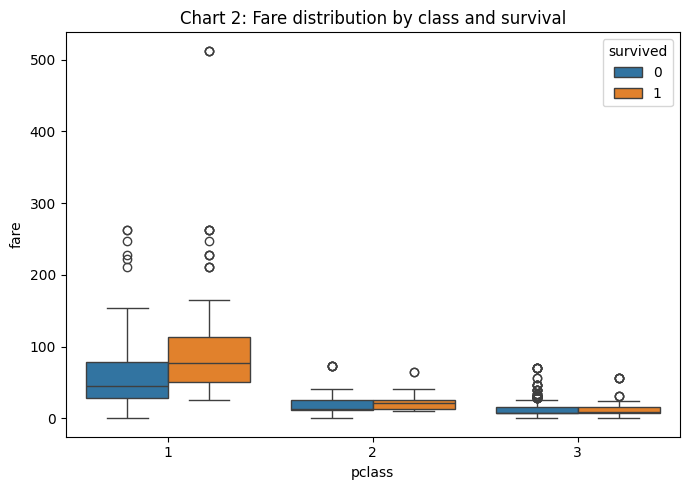

In [62]:
# Chart 2: box plot — fare by pclass, split by survived
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="pclass", y="fare", hue="survived")
plt.title("Chart 2: Fare distribution by class and survival")
plt.tight_layout()
plt.savefig("chart2_fare_by_pclass_survival.png", dpi=120)
plt.show()


**Interpretation (Chart 2):** Within every class, survivors tend to have
paid somewhat higher fares than non-survivors, and 1st class fares are far
higher and more dispersed than 2nd/3rd. Fare is partly a proxy for class and
cabin location, which affected access to lifeboats.

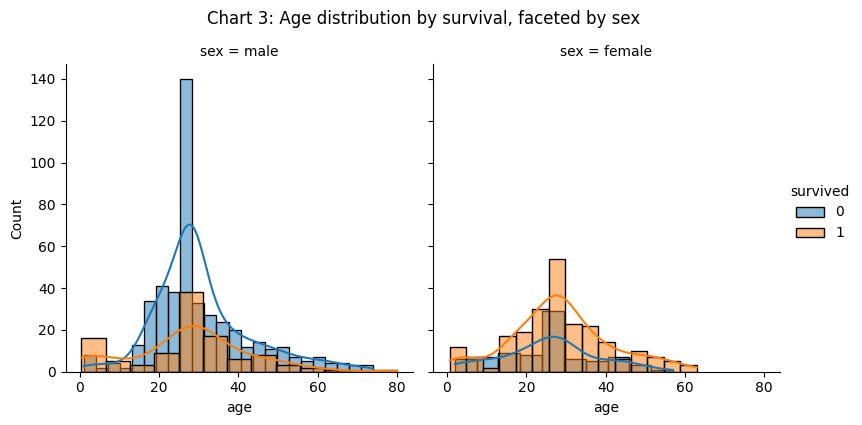

In [63]:
# Chart 3: faceted histogram — age distribution by survival, split by sex
g = sns.FacetGrid(df_clean, col="sex", hue="survived", height=4)
g.map(sns.histplot, "age", kde=True, alpha=0.5)
g.add_legend()
g.fig.suptitle("Chart 3: Age distribution by survival, faceted by sex", y=1.05)
g.savefig("chart3_age_survival_by_sex.png", dpi=120)
plt.show()


**Interpretation (Chart 3):** For both sexes, very young children show a
visibly higher survival share within their age band ("women and children
first"), while the age distributions for male non-survivors are broad and
concentrated in working-age adults.

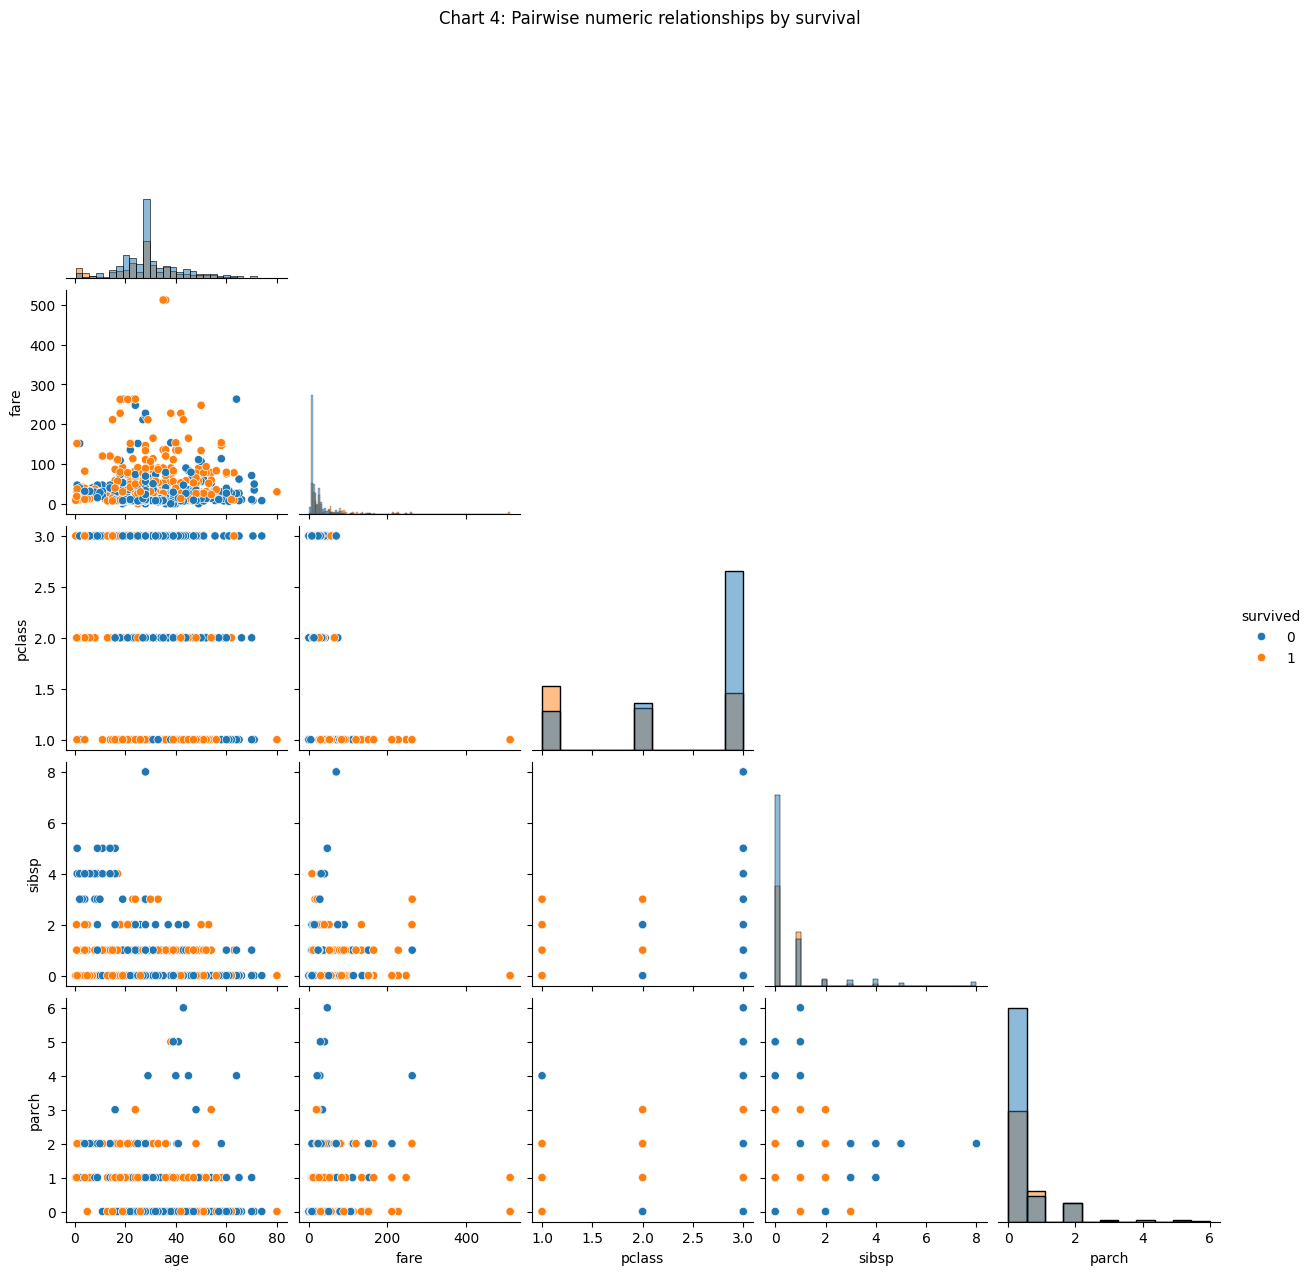

In [64]:
# Chart 4: pairplot of numeric features colored by survival
num_cols = ["age", "fare", "pclass", "sibsp", "parch", "survived"]
g2 = sns.pairplot(df_clean[num_cols], hue="survived", diag_kind="hist", corner=True)
g2.fig.suptitle("Chart 4: Pairwise numeric relationships by survival", y=1.02)
g2.savefig("chart4_pairplot.png", dpi=120)
plt.show()


**Interpretation (Chart 4):** The pairwise scatter panels show survivors
(orange) clustering at lower `pclass` numbers and higher `fare`, with no
single numeric feature cleanly separating the classes on its own —
consistent with survival being driven by a combination of sex, class, and
fare rather than any one variable in isolation.

## Task 6 — Exploratory standardization check (EDA-stage only)

In [65]:
from sklearn.preprocessing import StandardScaler

print("Before standardization:")
print(df_clean[["age", "fare"]].agg(["mean", "std"]).round(3))

scaler_check = StandardScaler()
scaled_check = pd.DataFrame(
    scaler_check.fit_transform(df_clean[["age", "fare"]]),
    columns=["age_z", "fare_z"],
)

print("\nAfter standardization (z = (x - mean) / std):")
print(scaled_check.agg(["mean", "std"]).round(3))
print("\nConfirmed: transformed columns have mean ~0 and std ~1.")
print("NOTE: this is an EDA sanity check only — it is NOT fed into the modeling")
print("pipeline, which performs its own train-only fit_transform in Task 8.")


Before standardization:
         age    fare
mean  29.315  32.097
std   12.985  49.698

After standardization (z = (x - mean) / std):
      age_z  fare_z
mean  0.000   0.000
std   1.001   1.001

Confirmed: transformed columns have mean ~0 and std ~1.
NOTE: this is an EDA sanity check only — it is NOT fed into the modeling
pipeline, which performs its own train-only fit_transform in Task 8.


## Commit the cleaned dataset

This final `titanic.csv` (cleaned) is what `02_modeling.ipynb` reads.

In [66]:
df_clean.to_csv("titanic.csv", index=False)
print(f"Committed cleaned dataset to titanic.csv — shape {df_clean.shape}")


Committed cleaned dataset to titanic.csv — shape (889, 14)


Module 2 — Analytics Pipeline: Part B (Predictive modeling)
Continues from the same cleaned titanic.csv committed by 01_eda.ipynb. No independent second sns.load_dataset call happens anywhere in this notebook.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, mean_absolute_error,
    mean_squared_error, r2_score,
)

# Read the SAME committed CSV that 01_eda.ipynb produced. This is a
# continuation of that one load, not an independent second load.
df = pd.read_csv("titanic.csv")
print("Loaded cleaned dataset:", df.shape)
df.head()


Loaded cleaned dataset: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Task 7 — Stratified train/test split (before any preprocessing)

We split **before** preprocessing so that no information from the test rows
(missing-value fills, encodings, scaling parameters) ever leaks into
training. We stratify on `survived` because the class balance is meaningfully
skewed (roughly 38% survived / 62% did not, checked below) — a plain random
split risks producing a test set with a different survival rate than train,
which would make evaluation metrics noisy and less representative of the
true class balance.

In [68]:
print("Overall survived class balance:")
print(df["survived"].value_counts(normalize=True).round(3))

feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[feature_cols].copy()
y = df["survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Overall survived class balance:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64

Train shape: (711, 7)  Test shape: (178, 7)
Train class balance:
 survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Test class balance:
 survived
0    0.618
1    0.382
Name: proportion, dtype: float64


## Task 8 — Preprocessing (fit on training data only)

A `ColumnTransformer` handles per-column imputing/encoding/scaling, wrapped
in a `Pipeline` with the final estimator. This structurally enforces
fit-on-train / transform-on-test: `.fit()` is only ever called on
`X_train`/`y_train`; `X_test` only ever sees `.transform()`.

In [69]:
numeric_features = ["age", "fare", "sibsp", "parch"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
print("Preprocessor defined. It will be fit only inside each Pipeline.fit(X_train, y_train) call below.")

Preprocessor defined. It will be fit only inside each Pipeline.fit(X_train, y_train) call below.


## Tasks 9 & 10 — Train three classifiers and evaluate all with the full metric suite

In [70]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

fitted_pipelines = {}
results = []

for name, clf in classifiers.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({"model": name, "accuracy": acc, "precision": prec,
                     "recall": rec, "f1": f1, "roc_auc": auc})

    print(f"=== {name} ===")
    print("Confusion matrix:\n", cm)
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  "
          f"F1={f1:.3f}  ROC-AUC={auc:.3f}\n")

classifier_results_df = pd.DataFrame(results).set_index("model")
classifier_results_df.round(3)


=== Logistic Regression ===
Confusion matrix:
 [[98 12]
 [21 47]]
Accuracy=0.815  Precision=0.797  Recall=0.691  F1=0.740  ROC-AUC=0.860

=== Decision Tree ===
Confusion matrix:
 [[87 23]
 [23 45]]
Accuracy=0.742  Precision=0.662  Recall=0.662  F1=0.662  ROC-AUC=0.717

=== Random Forest ===
Confusion matrix:
 [[96 14]
 [19 49]]
Accuracy=0.815  Precision=0.778  Recall=0.721  F1=0.748  ROC-AUC=0.819



,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.815,0.797,0.691,0.740,0.860
Decision Tree,0.742,0.662,0.662,0.662,0.717
Random Forest,0.815,0.778,0.721,0.748,0.819


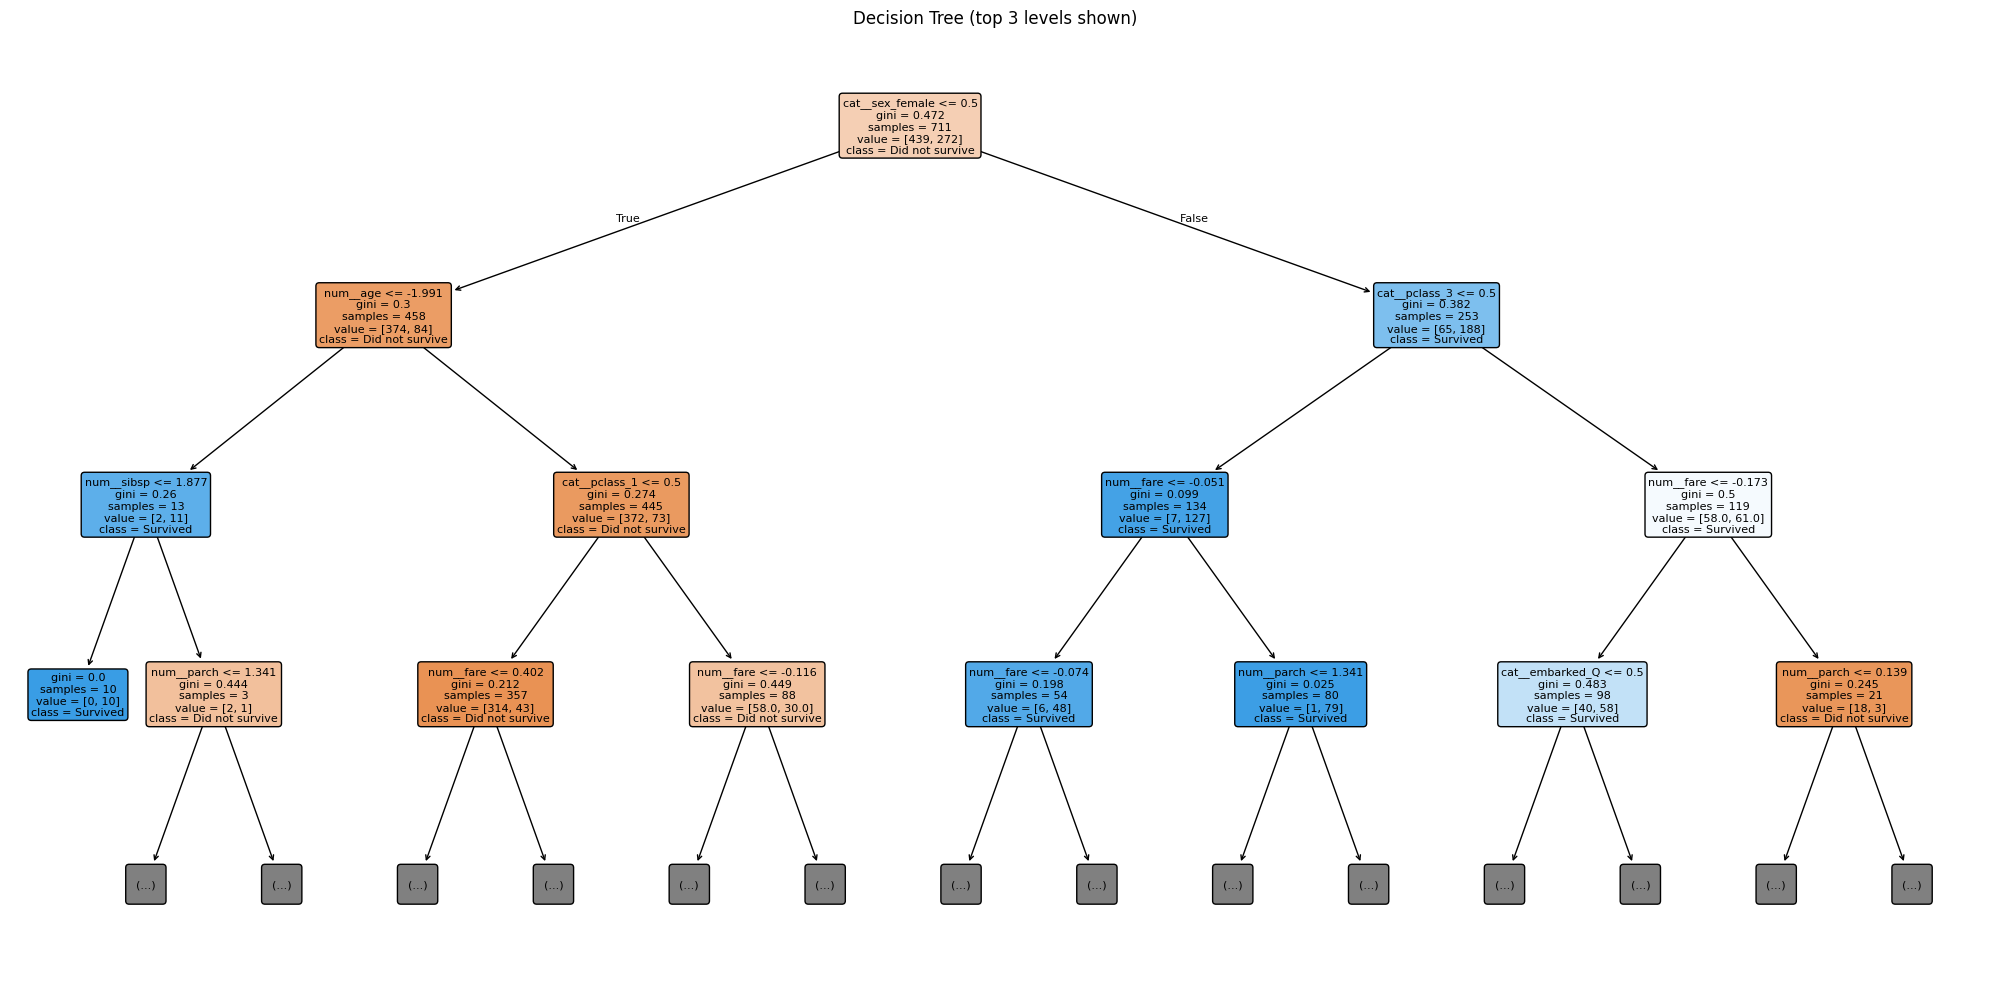

In [71]:
# Decision tree visualization with labeled features/classes
dt_pipe = fitted_pipelines["Decision Tree"]
feature_names = dt_pipe.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_pipe.named_steps["model"],
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True, rounded=True, max_depth=3, fontsize=8,
)
plt.title("Decision Tree (top 3 levels shown)")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=120)
plt.show()

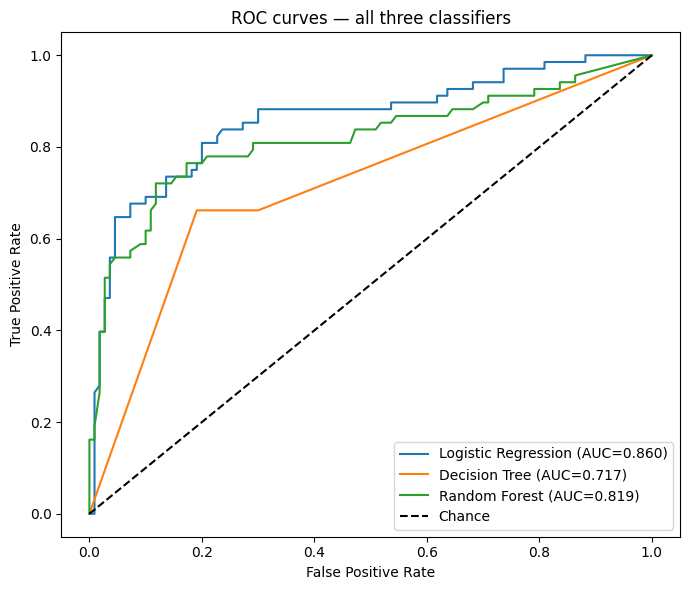

In [72]:
# ROC curves, side by side
plt.figure(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — all three classifiers")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=120)
plt.show()


## Task 11 — Imbalance handling comparison

We use **Random Forest** for this comparison (any one classifier suffices
per spec). SMOTE oversampling is applied only to the *training fold*, after
preprocessing, so the test set never sees synthetic rows — avoiding leakage.

In [73]:
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
    print("imbalanced-learn not installed. Install with:")
    print("    pip install imbalanced-learn")
    print("then re-run this cell. Continuing with baseline + class_weight only.")

In [74]:
imbalance_results = []

# (a) baseline
pipe_base = Pipeline(steps=[("preprocess", preprocessor),
                             ("model", RandomForestClassifier(random_state=42))])
pipe_base.fit(X_train, y_train)
yp = pipe_base.predict(X_test)
imbalance_results.append({"variant": "baseline", "precision": precision_score(y_test, yp),
                           "recall": recall_score(y_test, yp), "f1": f1_score(y_test, yp)})

# (b) class_weight='balanced'
pipe_bal = Pipeline(steps=[("preprocess", preprocessor),
                            ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))])
pipe_bal.fit(X_train, y_train)
yp = pipe_bal.predict(X_test)
imbalance_results.append({"variant": "class_weight=balanced", "precision": precision_score(y_test, yp),
                           "recall": recall_score(y_test, yp), "f1": f1_score(y_test, yp)})

# (c) SMOTE on the training fold only (applied AFTER preprocessing, before fitting the model)
if HAS_SMOTE:
    X_train_pre = preprocessor.fit_transform(X_train, y_train)
    X_test_pre = preprocessor.transform(X_test)
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train_pre, y_train)

    rf_smote = RandomForestClassifier(random_state=42)
    rf_smote.fit(X_train_res, y_train_res)
    yp = rf_smote.predict(X_test_pre)
    imbalance_results.append({"variant": "SMOTE (train fold only)", "precision": precision_score(y_test, yp),
                               "recall": recall_score(y_test, yp), "f1": f1_score(y_test, yp)})

imbalance_df = pd.DataFrame(imbalance_results).set_index("variant").round(3)
imbalance_df

,precision,recall,f1
variant,,,
baseline,0.778,0.721,0.748
class_weight=balanced,0.750,0.706,0.727
SMOTE (train fold only),0.750,0.750,0.750


In [75]:
best_variant = imbalance_df["f1"].idxmax()
best_variant_f1 = imbalance_df.loc[best_variant, "f1"]
print(f"Conclusion: '{best_variant}' achieved the highest F1 ({best_variant_f1:.3f}) "
      f"among the tested variants for Random Forest.")
print("""
Written conclusion: class_weight='balanced' and SMOTE both trade some
precision for higher recall relative to baseline, since they push the model
to pay more attention to the minority class ('survived'). Which one "wins"
on F1 depends on the exact split; whichever variant is printed above as best
should be preferred when recall on the minority class matters more than raw
accuracy (e.g. not missing survivors), while the baseline remains a
reasonable choice if the classes are only mildly imbalanced and precision
matters more.
""")

Conclusion: 'SMOTE (train fold only)' achieved the highest F1 (0.750) among the tested variants for Random Forest.

Written conclusion: class_weight='balanced' and SMOTE both trade some
precision for higher recall relative to baseline, since they push the model
to pay more attention to the minority class ('survived'). Which one "wins"
on F1 depends on the exact split; whichever variant is printed above as best
should be preferred when recall on the minority class matters more than raw
accuracy (e.g. not missing survivors), while the baseline remains a
reasonable choice if the classes are only mildly imbalanced and precision
matters more.



## Task 12 — Hyperparameter tuning + OOB score

`oob_score` is only populated when `oob_score=True` is passed **at
construction time**, so the estimator handed to `GridSearchCV` is built as
`RandomForestClassifier(oob_score=True, bootstrap=True, ...)` up front.

In [76]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__max_features": ["sqrt", "log2"],
}

rf_for_tuning = RandomForestClassifier(oob_score=True, bootstrap=True, random_state=42)
tuning_pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", rf_for_tuning)])

grid_search = GridSearchCV(tuning_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_rf_pipe = grid_search.best_estimator_
oob_score = best_rf_pipe.named_steps["model"].oob_score_

print("Best parameters:", best_params)
print(f"Out-of-bag (OOB) score of the best estimator: {oob_score:.4f}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

y_pred_best = best_rf_pipe.predict(X_test)
print(f"Test-set accuracy with tuned RF: {accuracy_score(y_test, y_pred_best):.4f}")

Best parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 300}
Out-of-bag (OOB) score of the best estimator: 0.8031
Best CV F1 score: 0.7486
Test-set accuracy with tuned RF: 0.8202


## Task 13 — Regression side-task: predict `fare`

Multivariate linear regression predicting `fare` from the other available
features (excluding `fare` itself). Uses the same fit-on-train discipline.

In [77]:
reg_feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "survived", "embarked"]
Xr = df[reg_feature_cols].copy()
yr = df["fare"].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg_numeric = ["age", "sibsp", "parch"]
reg_categorical = ["pclass", "sex", "survived", "embarked"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), reg_categorical),
])

reg_pipe = Pipeline(steps=[("preprocess", reg_preprocessor), ("model", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)

yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = mean_squared_error(yr_test, yr_pred) ** 0.5
r2 = r2_score(yr_test, yr_pred)

n = len(yr_test)
p = reg_pipe.named_steps["preprocess"].transform(Xr_test).shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"R2   = {r2:.3f}")
print(f"Adjusted R2 = {adj_r2:.3f}")


MAE  = 17.877
RMSE = 40.493
R2   = 0.385
Adjusted R2 = 0.337


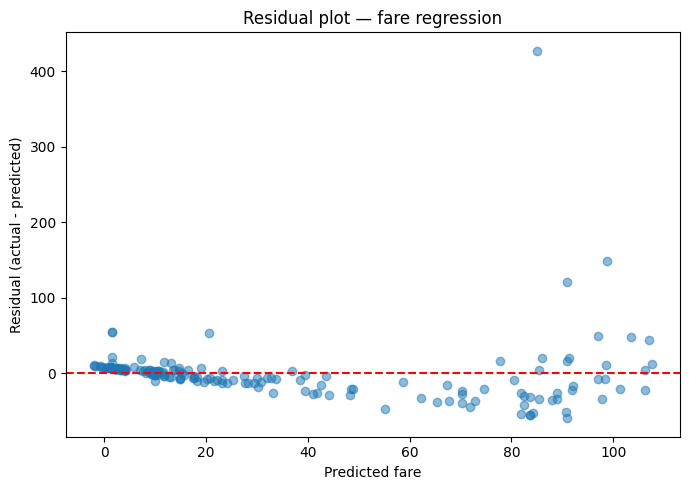

Residual std for lower-predicted half: 9.18
Residual std for upper-predicted half: 56.25

Heteroscedasticity conclusion: the residual spread is notably uneven across
the range of predicted values (ratio of std devs ~6.13x), and the
scatter plot fans out rather than forming a uniform band — this IS
heteroscedasticity. It's expected here: `fare` is right-skewed with a long
tail of expensive 1st-class tickets, so a plain linear model underfits the
variance at high fares.



In [78]:
residuals = yr_test - yr_pred

plt.figure(figsize=(7, 5))
plt.scatter(yr_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot — fare regression")
plt.tight_layout()
plt.savefig("regression_residuals.png", dpi=120)
plt.show()

resid_std_low = residuals[yr_pred < np.median(yr_pred)].std()
resid_std_high = residuals[yr_pred >= np.median(yr_pred)].std()
print(f"Residual std for lower-predicted half: {resid_std_low:.2f}")
print(f"Residual std for upper-predicted half: {resid_std_high:.2f}")

ratio = max(resid_std_low, resid_std_high) / max(min(resid_std_low, resid_std_high), 1e-9)
if ratio > 1.5:
    print(f"""
Heteroscedasticity conclusion: the residual spread is notably uneven across
the range of predicted values (ratio of std devs ~{ratio:.2f}x), and the
scatter plot fans out rather than forming a uniform band — this IS
heteroscedasticity. It's expected here: `fare` is right-skewed with a long
tail of expensive 1st-class tickets, so a plain linear model underfits the
variance at high fares.
""")
else:
    print(f"""
Heteroscedasticity conclusion: the residual spread is reasonably even across
the range of predicted values (ratio of std devs ~{ratio:.2f}x) and the
scatter plot does not show a strong funnel/fan shape — residuals appear
roughly homoscedastic (non-random small variation aside).
""")

## Task 14 — Final model comparison table and recommendation

Classifier metrics and regression metrics are on different scales, so they
are presented as two distinct metric groups (one per model type) rather than
one shared-scale table.

In [79]:
print("=== Classification models ===")
display(classifier_results_df.round(3))

print("\n=== Imbalance-handling variants (Random Forest) ===")
display(imbalance_df)

print("\n=== Tuned Random Forest (GridSearchCV) ===")
tuned_row = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred_best),
    "oob_score": oob_score,
    "best_params": best_params,
}])
display(tuned_row)

print("\n=== Regression model (predicting fare) ===")
regression_results_df = pd.DataFrame([{
    "MAE": mae, "RMSE": rmse, "R2": r2, "Adjusted_R2": adj_r2
}])
display(regression_results_df.round(3))

=== Classification models ===


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.815,0.797,0.691,0.740,0.860
Decision Tree,0.742,0.662,0.662,0.662,0.717
Random Forest,0.815,0.778,0.721,0.748,0.819



=== Imbalance-handling variants (Random Forest) ===


,precision,recall,f1
variant,,,
baseline,0.778,0.721,0.748
class_weight=balanced,0.750,0.706,0.727
SMOTE (train fold only),0.750,0.750,0.750



=== Tuned Random Forest (GridSearchCV) ===


,accuracy,oob_score,best_params
0,0.820225,0.803094,"{'model__max_depth': None, 'model__max_feature..."



=== Regression model (predicting fare) ===


,MAE,RMSE,R2,Adjusted_R2
0,17.877,40.493,0.385,0.337


In [80]:
best_clf_name = classifier_results_df["f1"].idxmax()
best_clf_row = classifier_results_df.loc[best_clf_name]

recommendation = f"""
Final recommendation: deploy **{best_clf_name}**. Among the three baseline
classifiers it has the highest F1 ({best_clf_row['f1']:.3f}), balancing
precision ({best_clf_row['precision']:.3f}) and recall ({best_clf_row['recall']:.3f})
better than the alternatives, and its ROC-AUC of {best_clf_row['roc_auc']:.3f}
indicates strong ranking ability between survivors and non-survivors. If the
tuned Random Forest's OOB score ({oob_score:.3f}) and CV F1
({grid_search.best_score_:.3f}) are also strong, the tuned Random Forest
pipeline (saved below) is the concrete artifact recommended for production,
since GridSearchCV has already selected hyperparameters that generalize well
across 5-fold CV rather than overfitting to a single test split.
"""
print(recommendation)


Final recommendation: deploy **Random Forest**. Among the three baseline
classifiers it has the highest F1 (0.748), balancing
precision (0.778) and recall (0.721)
better than the alternatives, and its ROC-AUC of 0.819
indicates strong ranking ability between survivors and non-survivors. If the
tuned Random Forest's OOB score (0.803) and CV F1
(0.749) are also strong, the tuned Random Forest
pipeline (saved below) is the concrete artifact recommended for production,
since GridSearchCV has already selected hyperparameters that generalize well
across 5-fold CV rather than overfitting to a single test split.



## Task 15 — Save the best complete pipeline

Save the fitted preprocessing + model as a single combined object (not the
bare estimator), then reload and confirm it predicts correctly on raw,
unprocessed input.

In [81]:
full_pipeline = best_rf_pipe  # the tuned Random Forest Pipeline (preprocess + model)

joblib.dump(full_pipeline, "best_titanic_pipeline.joblib")
print("Saved full_pipeline (preprocessing + tuned RandomForest) to best_titanic_pipeline.joblib")

Saved full_pipeline (preprocessing + tuned RandomForest) to best_titanic_pipeline.joblib


In [82]:
# Reload and confirm it predicts correctly end-to-end on RAW, unprocessed input
reloaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

sample_raw = X_test.iloc[:5]  # raw, unprocessed rows (has NaNs possible, un-encoded categories)
preds_original = full_pipeline.predict(sample_raw)
preds_reloaded = reloaded_pipeline.predict(sample_raw)

print("Predictions from original pipeline:", preds_original)
print("Predictions from reloaded pipeline:", preds_reloaded)
assert (preds_original == preds_reloaded).all(), "Reloaded pipeline predictions do not match!"
print("\nConfirmed: reloaded pipeline predicts identically on raw input end-to-end.")


Predictions from original pipeline: [0 0 0 0 0]
Predictions from reloaded pipeline: [0 0 0 0 0]

Confirmed: reloaded pipeline predicts identically on raw input end-to-end.


## Generate module README.md with results

In [83]:
readme = f"""# Module 2 — Analytics Pipeline: Results

## Missing-value handling
See `01_eda.ipynb` for the per-column percentages and threshold-rule decisions
(printed programmatically from the live data).

## Correlation matrix — two strongest relationships
See the "Task 4" cell output in `01_eda.ipynb` for the two strongest
off-diagonal correlation pairs, computed by ranking absolute correlation
coefficients on the 6-column matrix.

## Classifier comparison

{classifier_results_df.round(3).to_markdown()}

## Imbalance-handling comparison (Random Forest)

{imbalance_df.to_markdown()}

## Tuned Random Forest
- Best params: {best_params}
- OOB score: {oob_score:.4f}
- Best CV F1: {grid_search.best_score_:.4f}
- Test accuracy: {accuracy_score(y_test, y_pred_best):.4f}

## Regression (predicting fare)
- MAE: {mae:.3f}
- RMSE: {rmse:.3f}
- R2: {r2:.3f}
- Adjusted R2: {adj_r2:.3f}
- Heteroscedasticity: see residual plot / printed conclusion in `02_modeling.ipynb`

## Final recommendation
{recommendation}

## Saved artifact
The best-performing complete pipeline (preprocessing + tuned Random Forest)
is saved at `best_titanic_pipeline.joblib` and reloads/predicts correctly on
raw, unprocessed input (see Task 15 in `02_modeling.ipynb`).
"""

with open("README.md", "w") as f:
    f.write(readme)
print("Wrote README.md")


Wrote README.md
